# Industrial Predictive Maintenance System

## Problem Statement
The objective of this project is to Predict machine failure in advance to reduce downtime and maintenance cost.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [23]:
df = pd.read_csv("../data/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [24]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [25]:
df["Machine failure"].value_counts()
df["Machine failure"].value_counts(normalize=True)

Machine failure
0    0.9661
1    0.0339
Name: proportion, dtype: float64

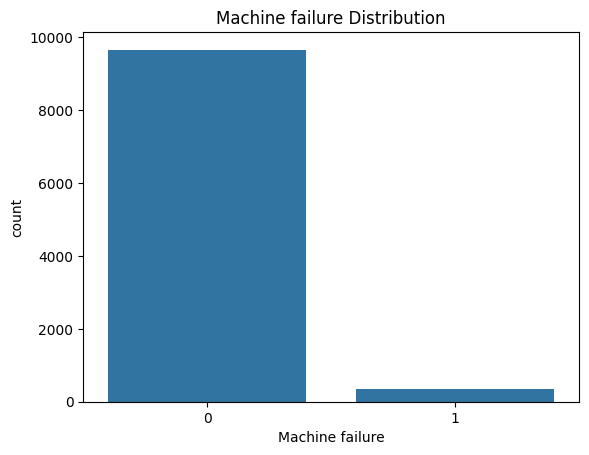

In [26]:
sns.countplot(x="Machine failure", data = df)
plt.title("Machine failure Distribution")
plt.show()

In [27]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


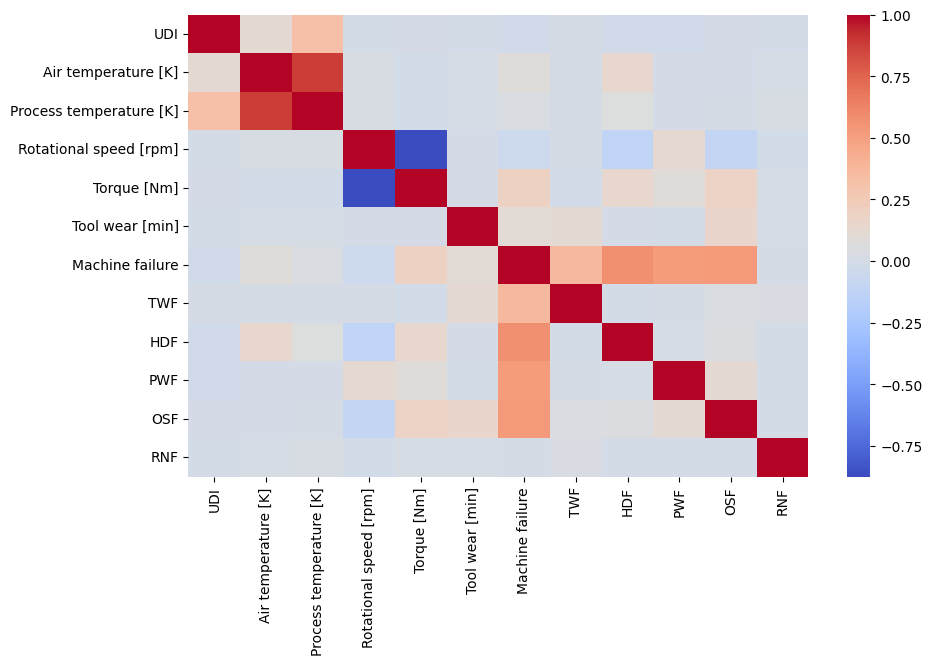

In [28]:
numeric_df = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), cmap="coolwarm")
plt.show()

In [29]:
# Check correlation of all features with Machine failure
numeric_df.corr()["Machine failure"].sort_values(ascending=False)

Machine failure            1.000000
HDF                        0.575800
OSF                        0.531083
PWF                        0.522812
TWF                        0.362904
Torque [Nm]                0.191321
Tool wear [min]            0.105448
Air temperature [K]        0.082556
Process temperature [K]    0.035946
RNF                        0.004516
UDI                       -0.022892
Rotational speed [rpm]    -0.044188
Name: Machine failure, dtype: float64

In [30]:
# Drop failure type columns to avoid data leakage
df = df.drop(["TWF", "HDF", "PWF", "OSF", "RNF"], axis=1)

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [31]:
# Drop categorical column 'Type'
df = df.drop("Type", axis=1)

In [34]:
# separate features and target variables 
X = df.drop("Machine failure", axis = 1)
y = df["Machine failure"]

#now checking the shape
X.shape, y.shape

((10000, 7), (10000,))

In [35]:
# X_train.dtypes

In [46]:
# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     random_state=42,
#     class_weight='balanced'
# )

===== Logistic Regression =====
Accuracy: 0.9685

Confusion Matrix:
[[1928    4]
 [  59    9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.69      0.13      0.22        68

    accuracy                           0.97      2000
   macro avg       0.83      0.57      0.60      2000
weighted avg       0.96      0.97      0.96      2000


===== Random Forest =====
Accuracy: 0.9855

Confusion Matrix:
[[1926    6]
 [  23   45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.88      0.66      0.76        68

    accuracy                           0.99      2000
   macro avg       0.94      0.83      0.87      2000
weighted avg       0.98      0.99      0.98      2000



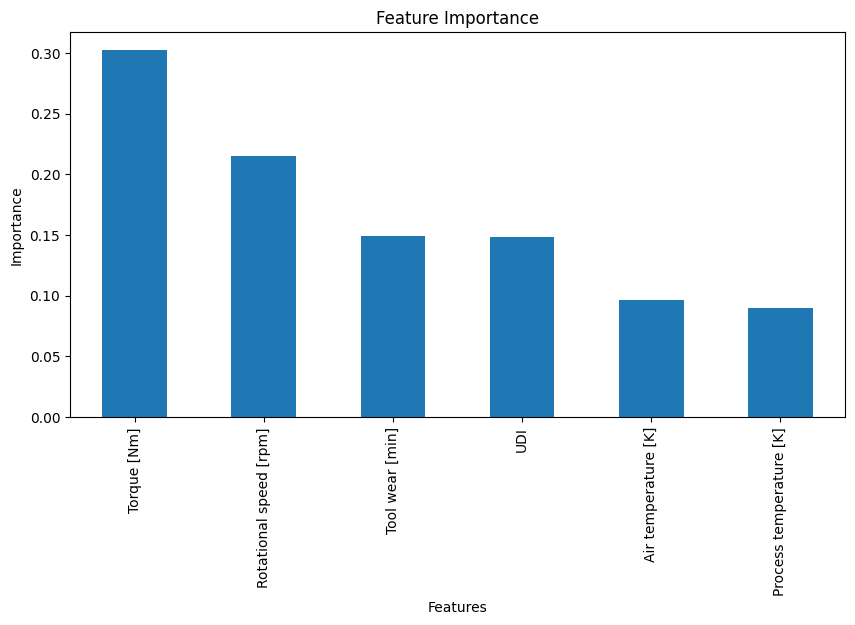


===== Model Comparison =====
Logistic Regression Accuracy: 0.9685
Random Forest Accuracy: 0.9855


In [45]:

X = X.drop(columns=['Product ID'])

# 1. Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 2. Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Logistic Regression Model
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

# 4. Prediction (Logistic)
y_pred_lr = lr_model.predict(X_test)

# 5. Evaluation (Logistic)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("===== Logistic Regression =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# 6. Random Forest Model
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7. Prediction (Random Forest)
y_pred_rf = rf_model.predict(X_test)

# 8. Evaluation (Random Forest)
print("\n===== Random Forest =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# 9. Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)

feature_importances.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# 10. Model Comparison
print("\n===== Model Comparison =====")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

In [54]:
# input_data = pd.DataFrame([{
#     'Air temperature [K]': 300,
#     'Process temperature [K]': 310,
#     'Rotational speed [rpm]': 1500,
#     'Torque [Nm]': 40,
#     'Tool wear [min]': 120
# }])

In [58]:
air_temp = float(input("Enter Air Temperature: "))
process_temp = float(input("Enter Process Temperature: "))
rpm = int(input("Enter Rotational Speed: "))
torque = float(input("Enter Torque: "))
tool_wear = int(input("Enter Tool Wear: "))

input_data = pd.DataFrame([{
    'Air temperature [K]': air_temp,
    'Process temperature [K]': process_temp,
    'Rotational speed [rpm]': rpm,
    'Torque [Nm]': torque,
    'Tool wear [min]': tool_wear
}])

print(predict_machine_failure(input_data))

Enter Air Temperature:  340
Enter Process Temperature:  360
Enter Rotational Speed:  3000
Enter Torque:  100
Enter Tool Wear:  300


[1]


In [59]:
def predict_machine_failure(data):
    # Drop unwanted columns if present
    data = data.drop(columns=['UDI', 'Product ID'], errors='ignore')
    
    # Match training columns
    data = data.reindex(columns=X.columns, fill_value=0)
    
    data_scaled = scaler.transform(data)
    return rf_model.predict(data_scaled)

In [60]:
predict_machine_failure(input_data)

array([1])